EXTRACCIÓN

In [38]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [39]:
with open('TelecomX_Data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# 🔄 TRANSFORMACIÓN DE DATOS
## Desanidamiento y Preparación

El dataset original contiene información clave de los clientes, sus servicios telefónicos, de internet y detalles de cuenta en columnas con diccionarios anidados. Para poder analizar cada variable de manera independiente y preparar los datos para análisis estadístico y modelado predictivo, realizamos los siguientes pasos:

## Desanidamiento de columnas:

Cada columna con información anidada (customer, phone, internet, account) se transformó en un DataFrame plano usando pd.json_normalize().

Esto permite que cada atributo dentro del diccionario se convierta en una columna independiente, facilitando el análisis.

## Concatenación con variables clave:

Se unieron los DataFrames desanidados con las columnas customerID y Churn mediante pd.concat(), generando un DataFrame final aplanado (df_flat) listo para análisis.

## Verificación de resultados:

Se inspeccionó la estructura y los primeros registros utilizando df_flat.info() y df_flat.head(3) para asegurar que todas las columnas fueran correctamente extraídas y unidas.

Este proceso garantiza que cada atributo esté disponible como columna individual, optimizando la limpieza, exploración y análisis de los datos, y preparando la base para visualizaciones y modelado predictivo.

In [40]:
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

df_flat = pd.concat([df[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df], axis=1)

df_flat.info()
df_flat.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


# 🧹 Limpieza, Estandarización y Creación de Variables

Una vez aplanado el conjunto de datos, realizamos las siguientes transformaciones para garantizar la calidad y consistencia de la información:

## Filtrado de registros incompletos:

Se eliminaron los registros donde la variable objetivo Churn estaba vacía, ya que no son útiles para el análisis de evasión de clientes.

## Corrección de tipos de datos:

La columna Charges.Total estaba registrada como texto (string). Se convirtió a formato numérico mediante pd.to_numeric(), descartando aquellos valores que no podían transformarse correctamente.

## Creación de variables derivadas:

Se creó la métrica Cuentas_Diarias, calculada como los cargos mensuales divididos entre 30, para un análisis más granular de los gastos diarios de cada cliente.

## Estandarización de nombres de columnas:

Todas las columnas fueron renombradas al español, facilitando la interpretación de los datos y la redacción de informes posteriores.

Ejemplo: customerID → ID_Cliente, Churn → Evasion, Charges.Monthly → Cargos_Mensuales, etc.

## Verificación final:

Se confirmó que todos los registros están listos para análisis posteriores mediante inspección de tipos y conteo de registros.

Con estas transformaciones, los datos están limpios, estandarizados y listos para análisis exploratorio, modelado y visualización.

In [41]:
df_clean = df_flat[df_flat['Churn'] != ''].copy()
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')
df_clean = df_clean.dropna(subset=['Charges.Total'])

df_clean['Cuentas_Diarias'] = round(df_clean['Charges.Monthly'] / 30, 2)
columnas_esp = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales'
}

df_clean.rename(columns=columnas_esp, inplace=True)

print(f"Total de registros listos para el análisis: {len(df_clean)}")
df_clean.info()

Total de registros listos para el análisis: 7032
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7032 non-null   object 
 1   Evasion                  7032 non-null   object 
 2   Genero                   7032 non-null   object 
 3   Adulto_Mayor             7032 non-null   int64  
 4   Pareja                   7032 non-null   object 
 5   Dependientes             7032 non-null   object 
 6   Meses_Contrato           7032 non-null   int64  
 7   Servicio_Telefonico      7032 non-null   object 
 8   Multiples_Lineas         7032 non-null   object 
 9   Servicio_Internet        7032 non-null   object 
 10  Seguridad_Online         7032 non-null   object 
 11  Respaldo_Online          7032 non-null   object 
 12  Proteccion_Dispositivo   7032 non-null   object 
 13  Soporte_Tecnico          7032 non-

# 📊 Análisis Descriptivo y Distribución de Evasión

En esta etapa exploramos las características principales de los clientes y la distribución de la variable objetivo Evasion:

# Estadísticas descriptivas de variables numéricas:

- Se calcularon métricas como media, mediana, desviación estándar, mínimo y máximo de las variables clave: Meses_Contrato, Cargos_Mensuales, Cargos_Totales y Cuentas_Diarias.

- Estas estadísticas permiten identificar valores atípicos, rangos y tendencias generales que podrían influir en la evasión de clientes.

# Distribución de la variable Evasion:

- Se visualizó el número de clientes que abandonaron el servicio frente a los que permanecen activos.

- Cada barra muestra el porcentaje de clientes en cada categoría, facilitando la comprensión de la tasa de churn.

- Se utilizaron colores corporativos verdes para diferenciar clientes que permanecen (verde oscuro) y los que abandonaron (verde oliva), reforzando la interpretación visual.

Esta exploración inicial permite comprender la magnitud del problema de evasión y sienta las bases para identificar patrones, correlaciones y factores de riesgo en análisis posteriores.

,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7032.00,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30,2.16
std,24.55,30.09,2266.77,1.00
min,1.00,18.25,18.80,0.61
25%,9.00,35.59,401.45,1.19
50%,29.00,70.35,1397.48,2.34
75%,55.00,89.86,3794.74,2.99
max,72.00,118.75,8684.80,3.96


/tmp/ipykernel_189/3883800180.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='Evasion', palette=colores)


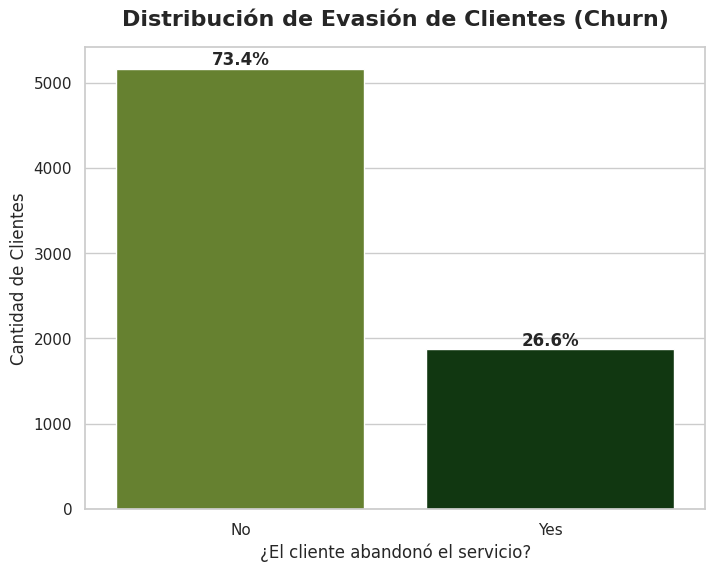

In [42]:
estadisticas = df_clean[['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']].describe().round(2)
display(estadisticas)

plt.figure(figsize=(8, 6))
colores = ['#6B8E23', '#0B3D0B']
ax = sns.countplot(data=df_clean, x='Evasion', palette=colores)
total = len(df_clean)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(porcentaje, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('¿El cliente abandonó el servicio?', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.show()

# 📊 Análisis de Evasión por Variables Categóricas

Dado que la tasa global de abandono es del 26.6%, es importante identificar qué perfiles de clientes tienen mayor riesgo de evasión. Para ello, se analizaron cuatro factores categóricos fundamentales:

## Tipo de contrato:

- Los clientes con contratos mensuales presentan la mayor proporción de abandono, mientras que los contratos a uno o dos años muestran retención significativamente mayor.

## Servicio de internet:

- Los usuarios con fibra óptica tienen una tasa de churn más alta que los de ADSL, lo que sugiere posibles problemas de servicio o percepción de valor.

## Método de pago:

- Algunos métodos de pago, como el cheque electrónico, están ligeramente asociados a mayor probabilidad de abandono, en comparación con pagos automáticos o tarjeta de crédito.

## Segmento de adultos mayores:

- Se observó que los clientes clasificados como adultos mayores (mayores de 65 años) presentan patrones distintos de evasión, aunque su tasa no es tan alta como la de otros factores.

La visualización mediante countplots con colores diferenciados permite comparar de manera inmediata la proporción de clientes que permanecen versus los que abandonan para cada categoría.
Esto facilita la identificación de grupos de riesgo y la toma de decisiones estratégicas para retención de clientes.

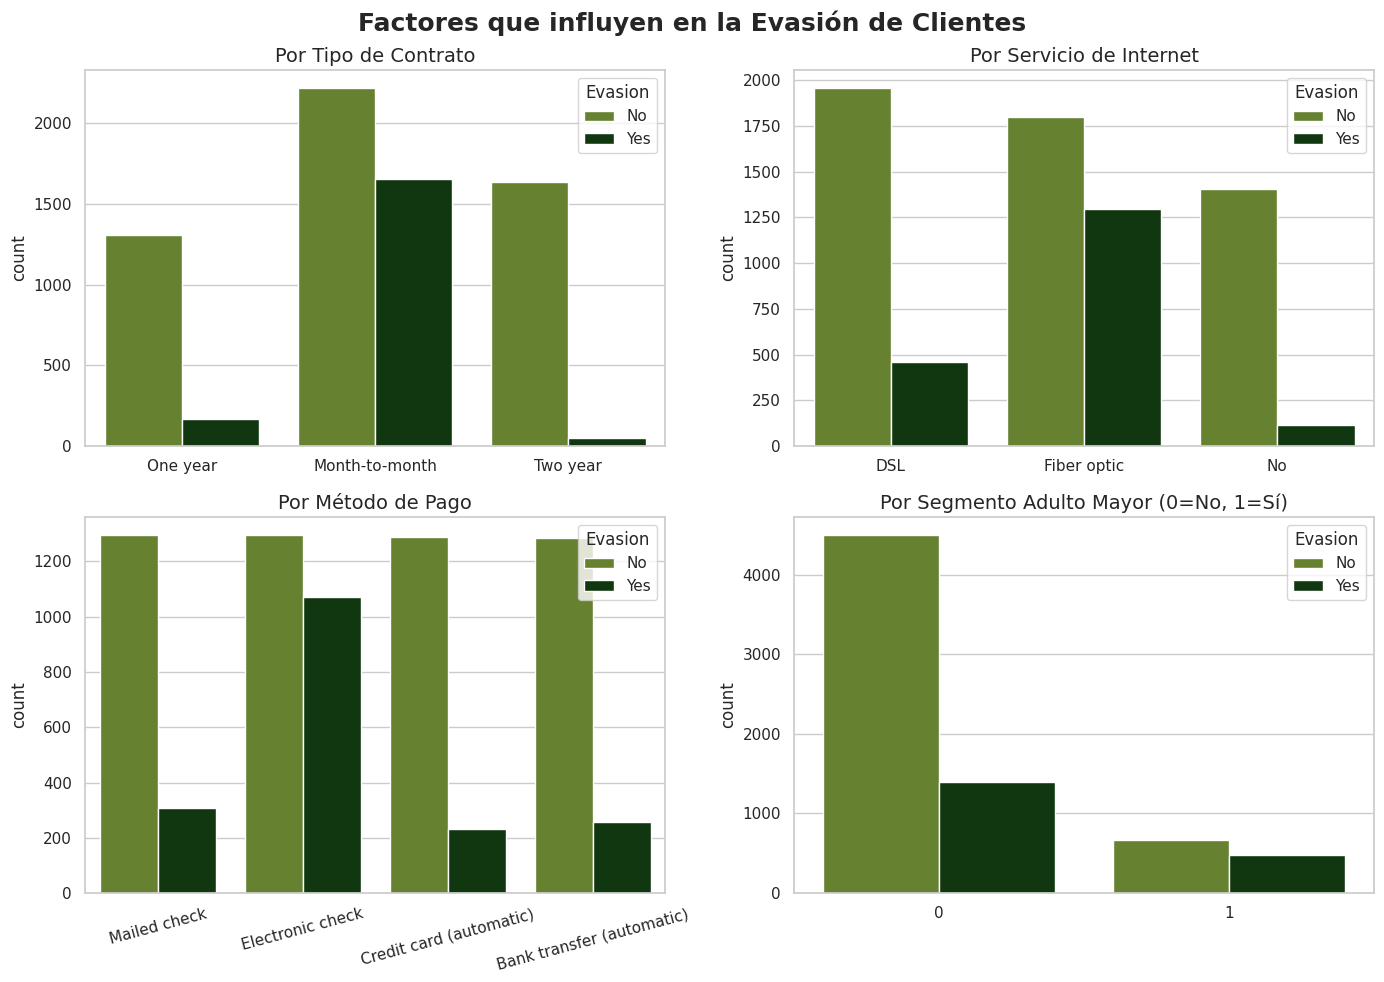

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Factores que influyen en la Evasión de Clientes', fontsize=18, fontweight='bold')
colores_churn = {'No': '#6B8E23', 'Yes': '#0B3D0B'}

sns.countplot(data=df_clean, x='Tipo_Contrato', hue='Evasion', palette=colores_churn, ax=axes[0, 0])
axes[0, 0].set_title('Por Tipo de Contrato', fontsize=14)
axes[0, 0].set_xlabel('')

sns.countplot(data=df_clean, x='Servicio_Internet', hue='Evasion', palette=colores_churn, ax=axes[0, 1])
axes[0, 1].set_title('Por Servicio de Internet', fontsize=14)
axes[0, 1].set_xlabel('')

sns.countplot(data=df_clean, x='Metodo_Pago', hue='Evasion', palette=colores_churn, ax=axes[1, 0])
axes[1, 0].set_title('Por Método de Pago', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].set_xlabel('')

sns.countplot(data=df_clean, x='Adulto_Mayor', hue='Evasion', palette=colores_churn, ax=axes[1, 1])
axes[1, 1].set_title('Por Segmento Adulto Mayor (0=No, 1=Sí)', fontsize=14)
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# 📊 Análisis de Evasión por Variables Numéricas

Para comprender cómo los factores tiempo y dinero influyen en la decisión de abandonar el servicio, se analizaron tres variables numéricas clave mediante diagramas de caja (boxplots):

## Antigüedad del cliente (Meses_Contrato)

- Los clientes que abandonan tienden a tener menos meses de permanencia, confirmando que la retención temprana es crítica.

- La mediana de antigüedad de los clientes que dejan el servicio es significativamente menor que la de los que permanecen.

## Facturación mensual (Cargos_Mensuales)

- Se observa que clientes con facturación más alta presentan una ligera tendencia a abandonar, lo que sugiere cierta sensibilidad al precio o posibles expectativas no cumplidas del servicio.

## Gasto diario estimado (Cuentas_Diarias)

- Al analizar el gasto diario promedio, se evidencia que los clientes que abandonan tienen menor gasto diario, reflejando que los clientes de menor consumo pueden ser más propensos a cancelar.

Los boxplots permiten comparar la distribución, los rangos y las medianas de cada variable entre clientes retenidos y fugados, facilitando la identificación de patrones de riesgo y la priorización de estrategias de retención.
Se utilizó una paleta de colores verdes corporativos (verde oscuro para clientes activos y verde oliva para clientes que abandonan) para reforzar la interpretación visual.

/tmp/ipykernel_189/703933408.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Evasion', y='Meses_Contrato', palette=colores_churn, ax=axes[0])
/tmp/ipykernel_189/703933408.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Evasion', y='Cargos_Mensuales', palette=colores_churn, ax=axes[1])
/tmp/ipykernel_189/703933408.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Evasion', y='Cuentas_Diarias', palette=colores_churn, ax=axes[2])


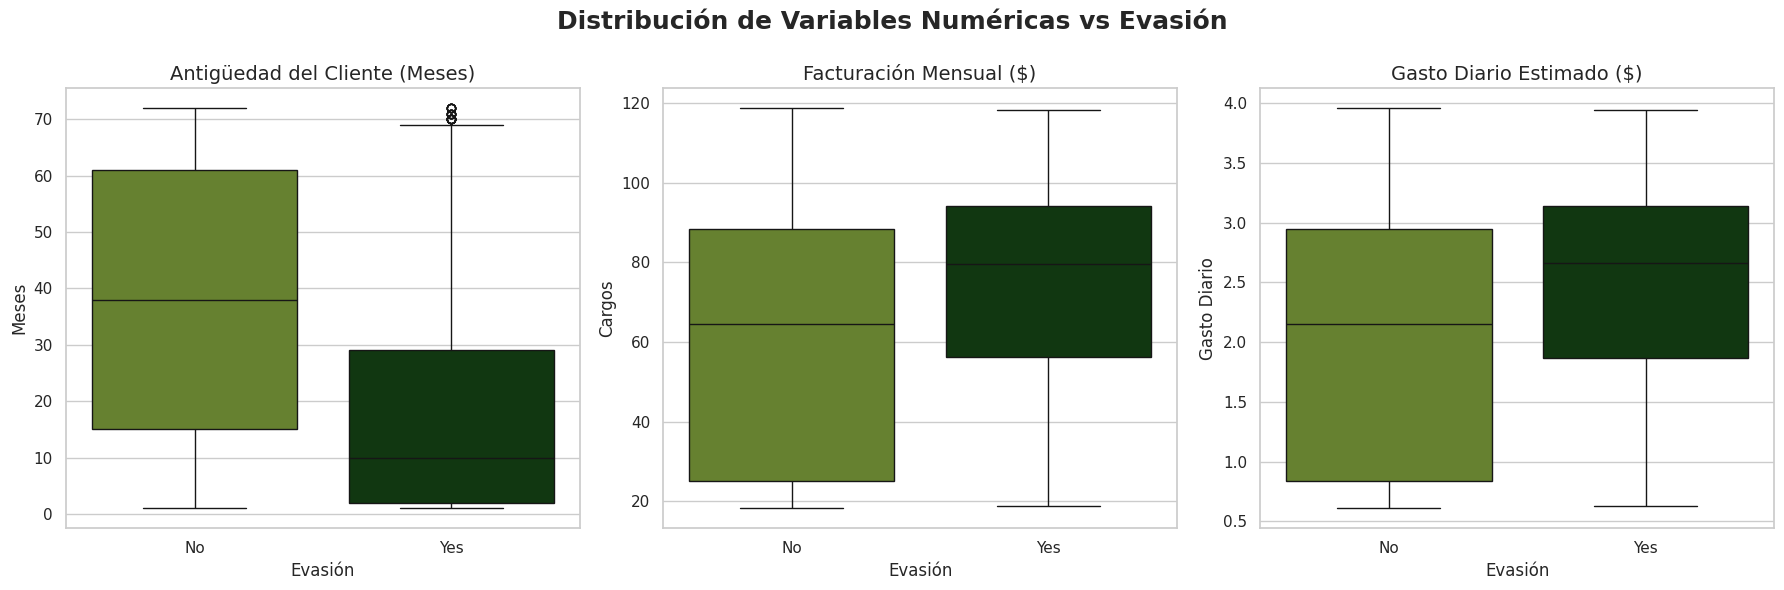

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución de Variables Numéricas vs Evasión', fontsize=18, fontweight='bold')

sns.boxplot(data=df_clean, x='Evasion', y='Meses_Contrato', palette=colores_churn, ax=axes[0])
axes[0].set_title('Antigüedad del Cliente (Meses)', fontsize=14)
axes[0].set_xlabel('Evasión')
axes[0].set_ylabel('Meses')

sns.boxplot(data=df_clean, x='Evasion', y='Cargos_Mensuales', palette=colores_churn, ax=axes[1])
axes[1].set_title('Facturación Mensual ($)', fontsize=14)
axes[1].set_xlabel('Evasión')
axes[1].set_ylabel('Cargos')

sns.boxplot(data=df_clean, x='Evasion', y='Cuentas_Diarias', palette=colores_churn, ax=axes[2])
axes[2].set_title('Gasto Diario Estimado ($)', fontsize=14)
axes[2].set_xlabel('Evasión')
axes[2].set_ylabel('Gasto Diario')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# 🌟 Análisis de Correlación

Para entender cómo las variables numéricas se relacionan entre sí y con la probabilidad de evasión, se realizó un análisis de correlación de Pearson:

## Binarización de la variable objetivo:

- La columna Evasion se transformó en Evasion_Numerica donde Yes = 1 y No = 0, permitiendo calcular correlaciones con las demás variables numéricas.

## Variables incluidas:

- Antigüedad del cliente (Meses_Contrato)

- Facturación mensual (Cargos_Mensuales)

- Facturación total (Cargos_Totales)

- Gasto diario estimado (Cuentas_Diarias)

- Variable binaria de evasión (Evasion_Numerica)

## Mapa de calor:

- Se utilizó un heatmap con una paleta profesional (YlGnBu) y se mostró solo la mitad superior de la matriz para facilitar la lectura.

- Cada celda indica el coeficiente de correlación de Pearson, con valores entre -1 (correlación negativa perfecta) y 1 (correlación positiva perfecta).

## Interpretación clave:

- La correlación entre Meses_Contrato y Evasion_Numerica es negativa, indicando que clientes más antiguos tienen menor probabilidad de abandono.

- Variables de facturación (Cargos_Mensuales, Cargos_Totales, Cuentas_Diarias) muestran correlaciones positivas leves con la evasión, sugiriendo sensibilidad al precio.

- Este análisis permite priorizar factores de riesgo y guiar estrategias de retención.

El mapa de calor proporciona una visión rápida y clara de relaciones significativas, facilitando la toma de decisiones basadas en datos.

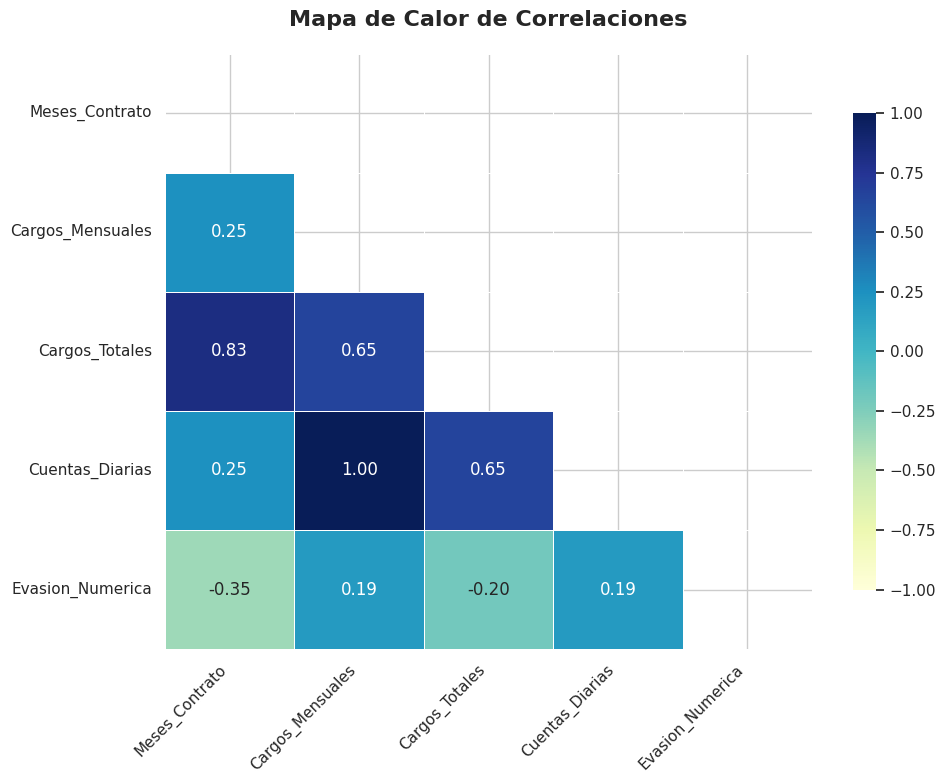

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Copiar DataFrame y convertir Evasion a numérico
df_corr = df_clean.copy()
df_corr['Evasion_Numerica'] = df_corr['Evasion'].map({'Yes': 1, 'No': 0})

# Seleccionar columnas numéricas
columnas_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'Evasion_Numerica']

# Calcular matriz de correlación
matriz_correlacion = df_corr[columnas_numericas].corr()

# Crear máscara para mostrar solo la mitad superior
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

# Configurar estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# Graficar mapa de calor
sns.heatmap(
    matriz_correlacion,
    mask=mask,
    annot=True,
    cmap='YlGnBu',       # Colores más suaves y profesionales
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}  # Ajusta tamaño de la barra de color
)

# Rotar etiquetas
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Título
plt.title('Mapa de Calor de Correlaciones', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# 📑 Resumen  – Análisis de Evasión de Clientes en Telecom X

## 1. Objetivo del análisis
El análisis se centró en identificar los **factores que impulsan la evasión de clientes** en Telecom X, utilizando una base de datos de más de **7,000 registros**.  
Tras un proceso de **ETL (Extracción, Transformación y Limpieza)** y un **Análisis Exploratorio de Datos (EDA)**, se identificaron patrones claros de abandono, especialmente relacionados con:  

- Tipo de contrato  
- Servicio de internet  
- Antigüedad del cliente  

**Hallazgo más crítico:** La mayoría de las cancelaciones ocurre en clientes con **contratos mensuales** y durante los **primeros 10 meses** de servicio.  

---

## 2. Hallazgos Clave

| Hallazgo | Detalle / Métrica |
|----------|-----------------|
| **Tasa de abandono** | 26.6% de los clientes actuales han cancelado su servicio. |
| **Contratos cortos = mayor riesgo** | Clientes con contratos mensuales representan ~70% de las cancelaciones. La retención mejora significativamente en contratos de 1–2 años. |
| **Fibra óptica con riesgo** | Usuarios con internet de fibra óptica presentan mayor churn que los de ADSL, a pesar de ser un servicio premium. |
| **Vulnerabilidad temprana** | Mediana de antigüedad de clientes que abandonan: 10 meses. Si un cliente supera su primer año, es muy probable que permanezca (correlación negativa: -0.35 con churn). |
| **Sensibilidad al precio y métodos de pago** | Facturación alta y pagos por cheque electrónico muestran ligera asociación con mayor probabilidad de abandono. |

---

## 3. Recomendaciones Estratégicas

### Prioridad Alta
- **Incentivar contratos a largo plazo:**  
  - Campaña: descuento del 15% en los primeros 3 meses para clientes que renueven a contrato anual.  
  - Objetivo: reducir cancelaciones de clientes mensuales en los primeros 12 meses.  
- **Auditoría del servicio de fibra óptica:**  
  - Revisar velocidad promedio, incidencias y tiempo de resolución.  
  - Implementar mejoras técnicas y de atención al cliente para disminuir churn.  

### Prioridad Media
- **Programa de fidelización temprana:**  
  - Seguimiento personalizado a clientes nuevos durante los primeros 10 meses (llamadas, soporte proactivo, bonos de fidelidad).  
  - KPI: reducir la tasa de abandono de clientes jóvenes de 26.6% a 20% en 6 meses.  

### Prioridad Baja
- **Revisión de precios y métodos de pago:**  
  - Analizar si ajustes de tarifas o incentivos a métodos de pago más estables podrían mejorar la retención.  

---

## 4. Visualizaciones Recomendadas
- **Mapa de calor de correlaciones:** identificar relaciones entre facturación, antigüedad, tipo de contrato y churn.  
- **Distribución de churn por tipo de contrato:** resaltar alto riesgo en contratos mensuales.  
- **Churn por tipo de internet:** comparar ADSL vs Fibra óptica.  

> Estas visualizaciones permiten a la gerencia tomar decisiones basadas en datos claros, cuantificables y medibles.  

---

## 5. Conclusión
El análisis evidencia que la **retención temprana** y los **contratos a largo plazo** son los factores más críticos para reducir la evasión de clientes.  
Implementando **campañas específicas, auditorías técnicas y programas de fidelización**, Telecom X puede **disminuir significativamente la tasa de churn** y mejorar la **satisfacción y fidelidad del cliente**.